In [1]:
import pandas as pd

# Define the path to your CSV file
file_path = './data/split/test.csv'

# Define the list of columns you want to read
desired_columns = ['tag', 'text', 'noise', 'clean_probability']

# Read the CSV file, specifying only the columns you want
df = pd.read_csv(
    file_path, 
    usecols=desired_columns
)

# Display the first few rows of the resulting DataFrame
print(df.head())

   tag                                               text  noise  \
0  763  Accordingly, under the Separation Agreement, s...      1   
1   64  Accordingly, under the Separation Agreement, s...      0   
2  399  The Company estimates that an additional $<spa...      0   
3  294  Due from related parties in the Condensed Cons...      0   
4  294  Due from related parties in the Condensed Cons...      0   

   clean_probability  
0           0.000428  
1           0.999626  
2           0.999236  
3           0.999566  
4           0.999564  


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

Tags excluded: [2, 1, 3, 9, 5] (Top 5)
Tags kept for plotting (Frequency < 20): 568 out of 1134
Filtered aggregated scatter plot successfully generated and saved as 'frequency_vs_mean_noise_filtered_cap_scatter.png'

First 5 rows of the FINAL aggregated data (Freq < 100):
     tag  mean_noise  tag_frequency
373  379    0.000000             17
395  401    0.000000             13
402  408    0.052632             19
413  419    0.000000             10
416  422    0.000000             11


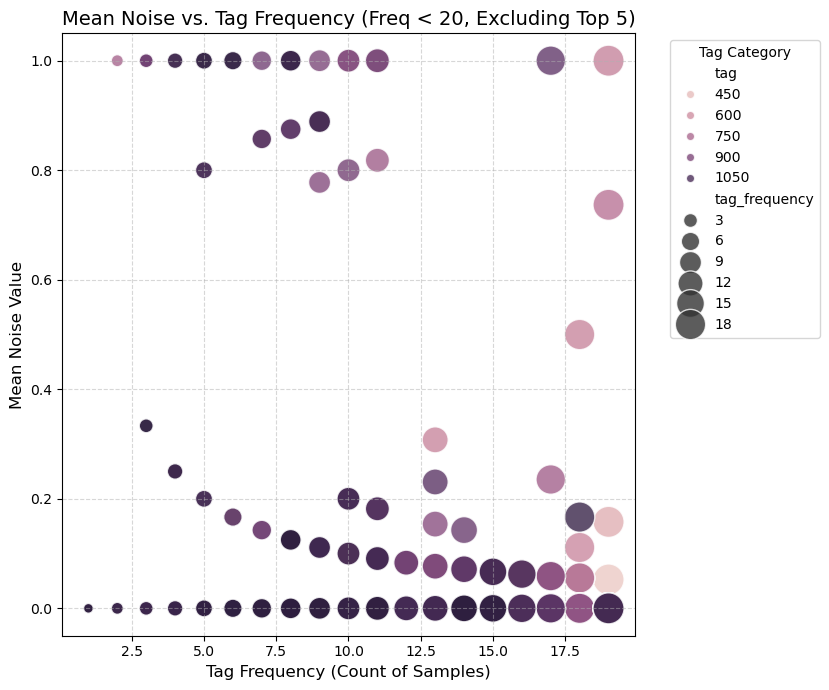

In [ ]:
 
 

# --- 2. Filter out Top 5 Most Frequent Tags ---

# Calculate all tag frequencies
all_tag_counts = df['tag'].value_counts()

# Identify the top 5 tags to exclude
tags_to_exclude = all_tag_counts.head(5).index.tolist()

# Filter the DataFrame to exclude these top 5 tags
df_filtered_top_5 = df[~df['tag'].isin(tags_to_exclude)].copy()


# --- 3. Data Aggregation (Calculate Frequency and Mean Noise on FILTERED Data) ---

# Calculate the mean noise for each remaining tag
mean_noise_filtered = df_filtered_top_5.groupby('tag')['noise'].mean().reset_index(name='mean_noise')

# Calculate the new frequency (count) of each remaining tag
tag_counts_filtered = df_filtered_top_5['tag'].value_counts().reset_index(name='tag_frequency')
tag_counts_filtered.columns = ['tag', 'tag_frequency']

# Merge the two summary tables
summary_df = pd.merge(mean_noise_filtered, tag_counts_filtered, on='tag')

# --- 4. Apply New Filter: Frequency < 100 ---
FREQUENCY_CAP = 200
summary_df_final = summary_df[summary_df['tag_frequency'] < FREQUENCY_CAP].copy()

print(f"Tags excluded: {tags_to_exclude} (Top 5)")
print(f"Tags kept for plotting (Frequency < {FREQUENCY_CAP}): {len(summary_df_final)} out of {len(summary_df)}")


# --- 5. Generate the Colored Scatter Plot using Seaborn ---
plt.figure(figsize=(10, 7))

# Use seaborn.scatterplot for coloring by 'tag' (hue)
sns.scatterplot(
    data=summary_df_final,
    x='tag_frequency', 
    y='mean_noise', 
    hue='tag',         
    size='tag_frequency', 
    sizes=(50, 500),    
    alpha=0.8          
)

# Customize the plot
plt.title(f'Mean Noise vs. Tag Frequency (Freq < {FREQUENCY_CAP}, Excluding Top 5)', fontsize=14)
plt.xlabel('Tag Frequency (Count of Samples)', fontsize=12)
plt.ylabel('Mean Noise Value', fontsize=12)
plt.legend(title='Tag Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(rect=[0, 0, 0.85, 1]) 

# --- 6. Save the Plot ---
plot_file = 'frequency_vs_mean_noise_filtered_cap_scatter.png'
plt.savefig(plot_file)
print(f"Filtered aggregated scatter plot successfully generated and saved as '{plot_file}'")

# Display the first 5 rows of the final summary data
print("\nFirst 5 rows of the FINAL aggregated data (Freq < 100):")
print(summary_df_final.head())

In [4]:
# --- 2. Filter Tags Based on Frequency (< 200) ---
FREQUENCY_CAP = 200

# Calculate the frequency of all tags
tag_counts = df['tag'].value_counts()

# Identify tags whose frequency is under the cap
low_frequency_tags = tag_counts[tag_counts < FREQUENCY_CAP].index.tolist()

# Filter the original DataFrame to keep only samples belonging to these low-frequency tags
df_filtered_raw = df[df['tag'].isin(low_frequency_tags)].copy()

# Check if there's any data left to analyze
if df_filtered_raw.empty:
    print("Error: The filtered dataset is empty. Cannot calculate statistics.")
    
# --- 3. Calculate the Mean Noise for the "Upper One" (Top Quartile) ---

# Calculate the 75th percentile (Q3) of the noise column in the filtered data
q3_noise = df_filtered_raw['noise'].quantile(0.75)

# Filter the data again to keep only rows with noise values above Q3
df_upper_quartile = df_filtered_raw[df_filtered_raw['noise'] >= q3_noise].copy()

# Calculate the mean noise for this top quartile
mean_noise_upper_quartile = df_upper_quartile['noise'].mean()

# --- 4. Print the Result ---
print("-" * 50)
print(f"Total samples in filtered dataset (Tags Freq < {FREQUENCY_CAP}): {len(df_filtered_raw)}")
print(f"75th Percentile (Q3) Noise Value: {q3_noise:.4f}")
print(f"Number of samples in Upper Quartile (Noise >= Q3): {len(df_upper_quartile)}")
print(f"Mean Noise of the Upper Quartile ('Upper One'): {mean_noise_upper_quartile:.4f}")
print("-" * 50)

--------------------------------------------------
Total samples in filtered dataset (Tags Freq < 200): 34622
75th Percentile (Q3) Noise Value: 0.0000
Number of samples in Upper Quartile (Noise >= Q3): 34622
Mean Noise of the Upper Quartile ('Upper One'): 0.0185
--------------------------------------------------


Grouped bar chart successfully generated and saved as 'tag_noise_counts_grouped_bar.png'

First 5 rows of the Noise Count Data:
     Noise_0_Count  Noise_1_Count
tag                              
1             7824              0
2            24700              0
3             1503            143
4             1188            101
5             1341              0


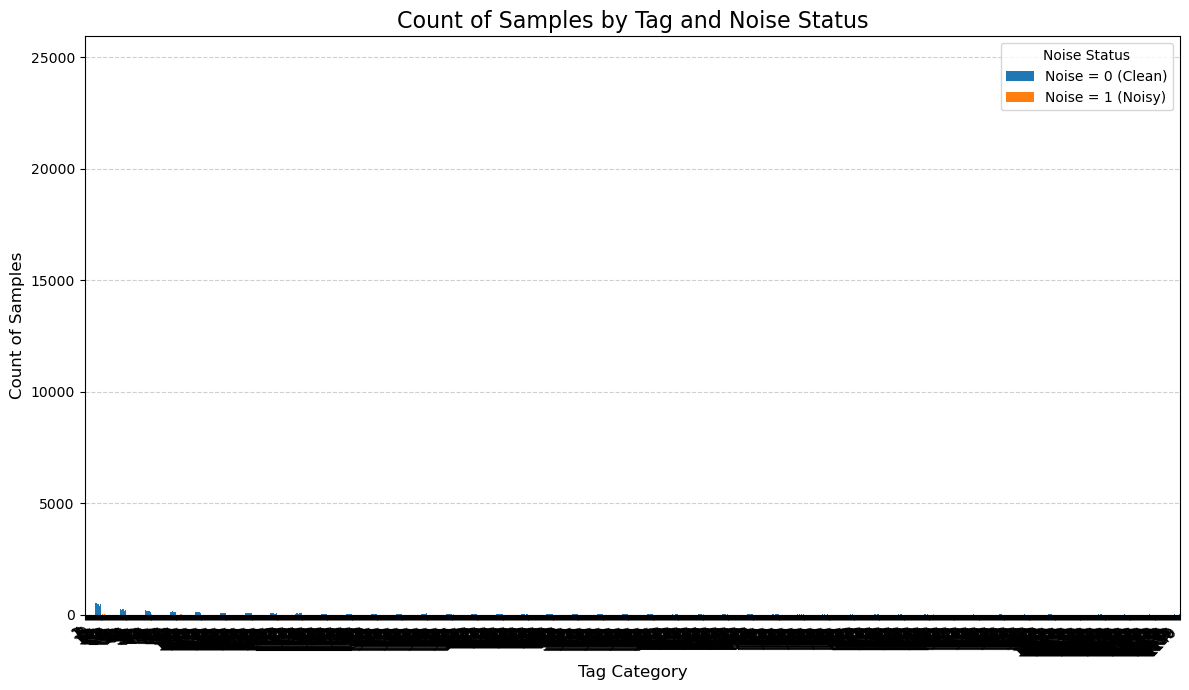

In [5]:
# --- 2. Data Aggregation (Count Noise=0 and Noise=1 per Tag) ---

# Use pd.crosstab to quickly get the counts for each combination of tag and noise
counts_df = pd.crosstab(df['tag'], df['noise'])

# Rename columns for clear plotting (assuming noise is binary 0/1)
counts_df.columns = ['Noise_0_Count', 'Noise_1_Count']

# --- 3. Generate the Grouped Bar Chart ---

plt.figure(figsize=(12, 7))

# Plot the counts as a grouped bar chart
counts_df.plot(kind='bar', figsize=(12, 7), ax=plt.gca())

# Customize the plot
plt.title('Count of Samples by Tag and Noise Status', fontsize=16)
plt.xlabel('Tag Category', fontsize=12)
plt.ylabel('Count of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Noise Status', labels=['Noise = 0 (Clean)', 'Noise = 1 (Noisy)'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# --- 4. Save the Plot ---
plot_file = 'tag_noise_counts_grouped_bar.png'
plt.savefig(plot_file)
print(f"Grouped bar chart successfully generated and saved as '{plot_file}'")

# Display the first 5 rows of the count data
print("\nFirst 5 rows of the Noise Count Data:")
print(counts_df.head())

Total unique tags in full dataset: 1139
Tags kept for plotting (Frequency between 100 and 10000): 128
Filtered grouped bar chart successfully generated and saved as 'tag_noise_counts_freq_10_to_50_bar.png'

First 5 rows of the FILTERED Noise Count Data:
     Noise_0_Count  Noise_1_Count
tag                              
1             7824              0
3             1503            143
4             1188            101
5             1341              0
6             1228              0


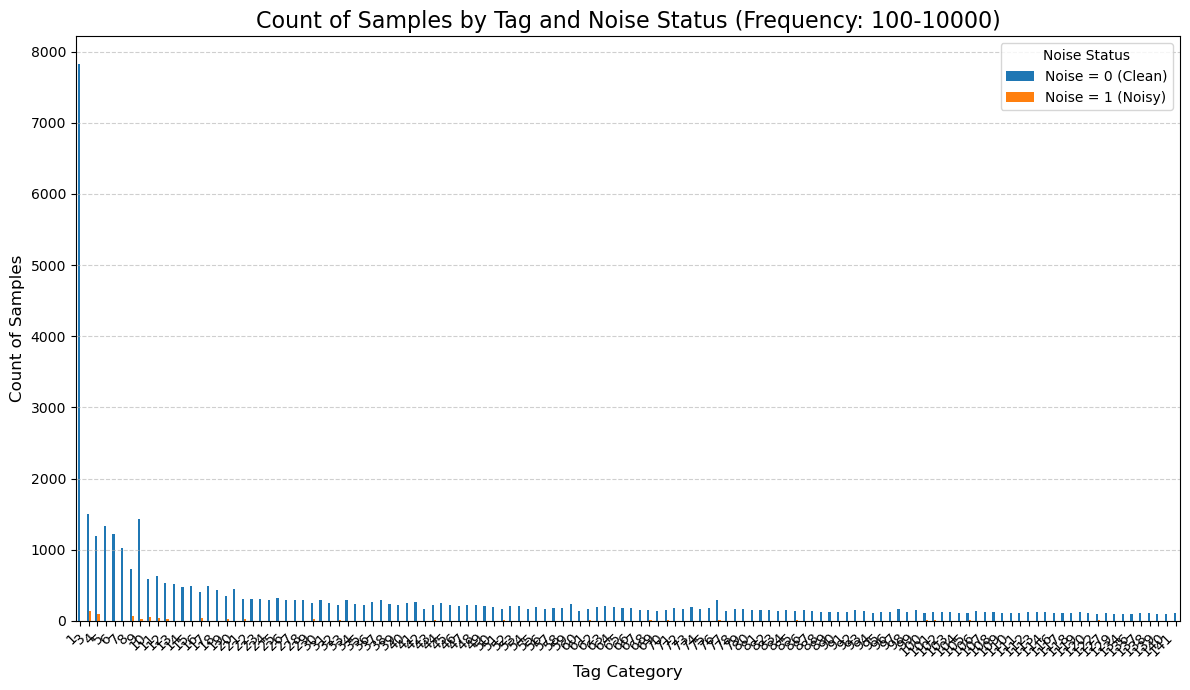

In [6]:
 
MIN_FREQ = 100
MAX_FREQ = 10000


# --- 2. Data Aggregation (Count Noise=0 and Noise=1 per Tag) ---

# Use pd.crosstab to get the counts for each combination of tag and noise
counts_df = pd.crosstab(df['tag'], df['noise'])

# Rename columns for clarity
counts_df.columns = ['Noise_0_Count', 'Noise_1_Count']

# --- 3. Apply Filter: Total Frequency >= 10 and < 50 ---

# Calculate the total frequency for each tag
counts_df['Total_Frequency'] = counts_df['Noise_0_Count'] + counts_df['Noise_1_Count']

# Filter the DataFrame based on the range
filtered_counts_df = counts_df[
    (counts_df['Total_Frequency'] >= MIN_FREQ) & (counts_df['Total_Frequency'] < MAX_FREQ)
].drop(columns=['Total_Frequency'])

print(f"Total unique tags in full dataset: {len(counts_df)}")
print(f"Tags kept for plotting (Frequency between {MIN_FREQ} and {MAX_FREQ}): {len(filtered_counts_df)}")


# --- 4. Generate the Grouped Bar Chart ---

plt.figure(figsize=(12, 7))

# Plot the filtered counts as a grouped bar chart
filtered_counts_df.plot(kind='bar', figsize=(12, 7), ax=plt.gca())

# Customize the plot
plt.title(f'Count of Samples by Tag and Noise Status (Frequency: {MIN_FREQ}-{MAX_FREQ})', fontsize=16)
plt.xlabel('Tag Category', fontsize=12)
plt.ylabel('Count of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Noise Status', labels=['Noise = 0 (Clean)', 'Noise = 1 (Noisy)'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# --- 5. Save the Plot ---
plot_file = 'tag_noise_counts_freq_10_to_50_bar.png'
plt.savefig(plot_file)
print(f"Filtered grouped bar chart successfully generated and saved as '{plot_file}'")

# Display the first 5 rows of the filtered count data
print("\nFirst 5 rows of the FILTERED Noise Count Data:")
print(filtered_counts_df.head())

In [7]:
print(filtered_counts_df)

     Noise_0_Count  Noise_1_Count
tag                              
1             7824              0
3             1503            143
4             1188            101
5             1341              0
6             1228              0
..             ...            ...
137            115              0
138            108              0
139            102              0
140            103              0
141            119              0

[128 rows x 2 columns]
